# Lab 7 - Ruido

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

## Ejercicio 1.

Considere una neurona LIF sujeta a ruido blanco con valores de intensidad $\sigma = [1, 2, 3]$. Para cada valor simule la neurona hasta que genere por lo menos 1000 spikes.

1. Muestre en cada caso el gráfico del potencial de membrana en el tiempo en una ventana de tiempo corta
2. Calcule la distribución del ISI
3. Calcule la ACF del tren de spikes emitido
4. Calcule el espectro de potencia del tren de spikes.

Use el método de Euler Maruyama con $dt = 0.1$, use para el ejercicio los siguientes parámetros.

- $R = 1$, $I_{det} = 10$, $V_{rest}=V_{reset}=-65mV$, $V_{th} = -50mV$, $\tau_m = 10$



In [ ]:
# Parámetros:

Vth = -50
Vrest = -65
Vreset = Vrest
Tm = 10
R = 1
Idet = 10
dt = 0.1
sigma1, sigma2, sigma3 = [1, 2, 3]

In [ ]:
def simulacion_lif(sigma, Vth, Vrest, Vreset, Tm, R, Idet, dt):
  V = np.array([Vrest])
  tiempo_spike = np.array([])
  iter = 1
  tope = 10000
  Vant = Vrest
  tsim = 0
  while len(tiempo_spike) < 1000:
      iter+=1
      y = np.random.normal(0, 1)
      Vsig = Vant + dt * (-(Vant-Vrest)+R*Idet)/Tm + sigma*np.sqrt(dt)*y

      if Vsig >= Vth:
        Vsig = Vreset
        tiempo_spike = np.append(tiempo_spike, tsim+dt)

      if iter <=tope:
        V = np.append(V, Vsig)
      tsim += dt
      Vant = Vsig
  t_fin = iter * dt
  t = np.arange(0, dt*tope, dt)
  plt.figure(figsize=(10, 5))
  plt.suptitle(f"Sigma: {sigma}")

  # Graficar el potencial de membrana:
  plt.subplot(2, 2, 1)
  plt.plot(t,V)
  plt.scatter(tiempo_spike[tiempo_spike<dt*tope], np.ones(len(tiempo_spike[tiempo_spike<dt*tope]))*Vth, color='red')
  plt.xlabel('Tiempo (ms)')
  plt.ylabel('Potencial (mV)')
  plt.title('Potencial de membrana')

  # Graficar el ISI.

  # Calculo del ISI
  ISI = np.diff(tiempo_spike)

  plt.subplot(2, 2, 2)
  plt.hist(ISI, bins = 50)
  plt.xlabel('ISI (s)')
  plt.ylabel('Frecuencia')
  plt.title('Histograma del ISI')

  # Autocorrelación del tren de spikes:
  part = np.min(ISI)//2
  extremos = np.arange(0, t_fin+dt, part)
  tren_spike = np.zeros(len(extremos))
  for i in range(len(extremos)-1):
    if tiempo_spike[(tiempo_spike < extremos[i+1]) & (tiempo_spike >= extremos[i])].size > 0:
      tren_spike[i] = 1
  tren_spike -= tren_spike.mean()
  tren_spike /= tren_spike.std()
  autocorrelacion = signal.correlate(tren_spike,tren_spike)


  plt.subplot(2, 2, 3)
  tiempos = np.linspace(0, 3000, len(autocorrelacion[len(autocorrelacion)//2+1:len(autocorrelacion)//2+1+3000]))
  plt.plot(tiempos,autocorrelacion[len(autocorrelacion)//2+1:len(autocorrelacion)//2+1+3000])
  plt.xlabel('Retardo')
  plt.ylabel('Autocorrelación')
  plt.title('Función de autocorrelación (solo la mitad)')



  # Graficar la frecuencia espectral.
  plt.subplot(2, 2, 4)
  frecuencia, potencia= signal.periodogram(tren_spike,fs = 1/dt)
  plt.plot(frecuencia,potencia)
  plt.xlabel('Frecuencia')
  plt.ylabel('Potencia')
  plt.title('Frecuencia espectral')

  plt.tight_layout()
  plt.show()

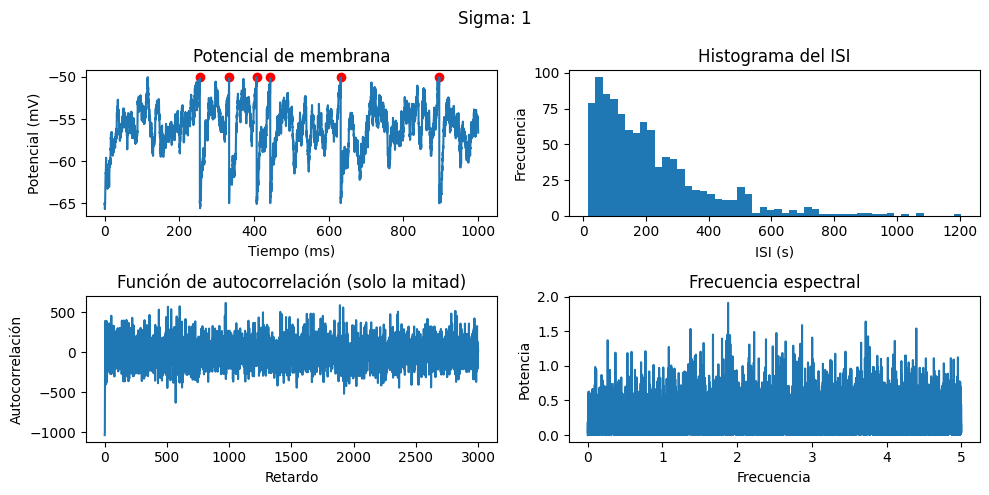

In [ ]:
simulacion_lif(sigma1, Vth, Vrest, Vreset, Tm, R, Idet, dt)

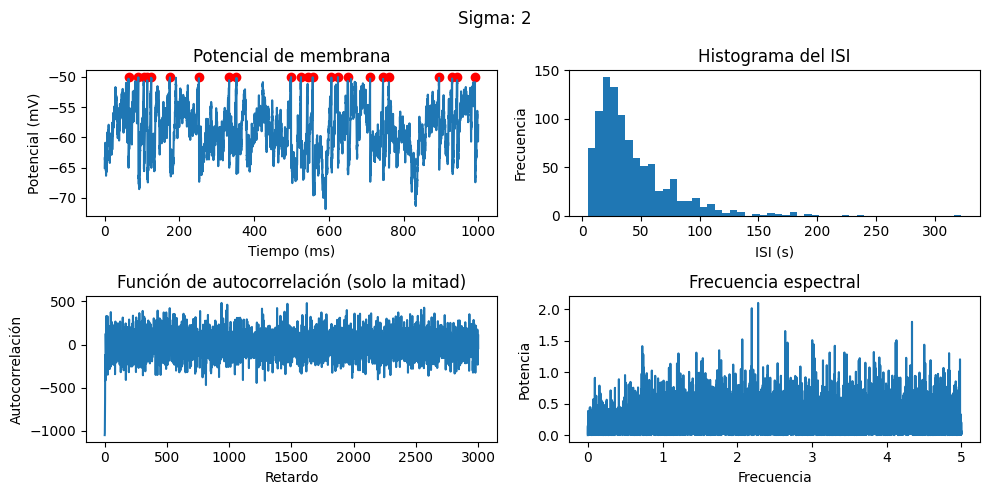

In [ ]:
simulacion_lif(sigma2, Vth, Vrest, Vreset, Tm, R, Idet, dt)

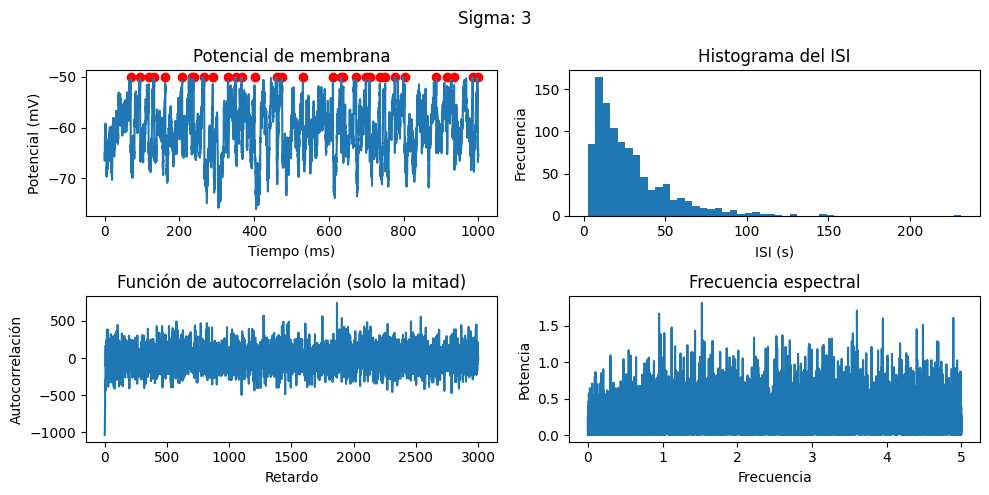

In [ ]:
simulacion_lif(sigma3, Vth, Vrest, Vreset, Tm, R, Idet, dt)

## Ejercicio 2.

Con los mismos parámetros anteriores repita el ejercicio 1 pero ahora suponga que el ruido es de color y éste es producido a su vez por un proceso de Ornstein-Ulhenbeck con tiempo de correlación $\tau_s = 20ms$.

1. Muestre la función de autocorrelación y el espectro de la corriente $I_{noise}(t)$ en cada caso
2. Muestre las mismas gráficas del ejercicio 2 y discuta las diferencias

In [ ]:
# Parámetros:

Vth = -50
Vrest = -65
Vreset = Vrest
Tm = 10
R = 1
Idet = 10
dt = 0.1
sigma1, sigma2, sigma3 = [1, 2, 3]
Ts = 20

In [ ]:
def simulacion_lif_noise(sigma, Vth, Vrest, Vreset, Tm, R, Idet, dt, Ts):
  Inoise = np.random.normal(0, sigma)
  V = np.array([Vrest])
  tiempo_spike = np.array([])
  iter = 1
  tope = 100000
  Vant = Vrest
  tsim = 0
  Vector_I_noise = np.array([Inoise])
  while len(tiempo_spike) < 100:
      iter+=1
      y = np.random.normal(0, 1)
      Vsig = Vant + dt * (-(Vant-Vrest)+R*Idet + R*Inoise)/Tm
      Inoise +=  (- Inoise/Ts)*dt + sigma1*np.sqrt(dt)*y
      Vector_I_noise = np.append(Vector_I_noise, Inoise)

      if Vsig >= Vth:
        Vsig = Vreset
        tiempo_spike = np.append(tiempo_spike, tsim+dt)

      if iter <=tope:
        V = np.append(V, Vsig)
      tsim += dt
      Vant = Vsig
  t_fin = iter * dt
  t = np.linspace(0, dt*tope, len(V))

  plt.figure(figsize=(10, 5))
  plt.suptitle(f"Sigma: {sigma}")

  # Graficar el potencial de membrana:
  plt.subplot(2, 3, 1)
  plt.plot(t,V)
  plt.scatter(tiempo_spike[tiempo_spike<dt*tope], np.ones(len(tiempo_spike[tiempo_spike<dt*tope]))*Vth, color='red')
  plt.xlabel('Tiempo (ms)')
  plt.ylabel('Potencial (mV)')
  plt.title('Potencial de membrana')

  # Graficar el ISI.

  # Calculo del ISI
  plt.subplot(2, 3, 2)
  ISI = np.diff(tiempo_spike)
  plt.hist(ISI, bins = 50)
  plt.xlabel('ISI (s)')
  plt.ylabel('Frecuencia')
  plt.title('Histograma del ISI')

  # Autocorrelación del tren de spikes:
  part = np.min(ISI)//2
  extremos = np.arange(0, t_fin+dt, part)
  tren_spike = np.zeros(len(extremos))
  for i in range(len(extremos)-1):
    if tiempo_spike[(tiempo_spike < extremos[i+1]) & (tiempo_spike >= extremos[i])].size > 0:
      tren_spike[i] = 1

  tren_spike -= tren_spike.mean()
  tren_spike /= tren_spike.std()

  autocorrelacion = signal.correlate(tren_spike,tren_spike)

  plt.subplot(2, 3, 3)
  tiempos = np.linspace(0, 3000, len(autocorrelacion[len(autocorrelacion)//2+1:len(autocorrelacion)//2+1+3000]))
  plt.plot(tiempos,autocorrelacion[len(autocorrelacion)//2+1:len(autocorrelacion)//2+1+3000])
  plt.xlabel('Retardo')
  plt.ylabel('Autocorrelación')
  plt.title('Autocorrelación (mitad)')

  # Graficar la frecuencia espectral.
  plt.subplot(2, 3, 4)
  frecuencia, potencia= signal.periodogram(tren_spike,fs = 1/part)
  plt.plot(frecuencia,potencia)
  plt.xlabel('Frecuencia')
  plt.ylabel('Potencia')
  plt.title('Frecuencia espectral')

  Vector_I_noise -= Vector_I_noise.mean()
  Vector_I_noise /= Vector_I_noise.std()

  plt.subplot(2, 3, 5)
  autocorrelacion_inose = signal.correlate(Vector_I_noise[:100000],Vector_I_noise[:100000],mode="full")[100000-1:]

  tiempos = np.linspace(0, len(autocorrelacion_inose)*dt, len(autocorrelacion_inose))
  plt.plot(tiempos,autocorrelacion_inose)
  plt.xlim(0, 100)
  plt.xlabel('Retardo')
  plt.ylabel('Autocorrelación Inoise(t)')
  plt.title('AC/2 Inoise(t)')

  # Graficar la frecuencia espectral.
  plt.subplot(2, 3, 6)
  frecuencia, potencia= signal.periodogram(Vector_I_noise,fs = 1/part)
  plt.plot(frecuencia,potencia)
  plt.xlabel('Frecuencia')
  plt.ylabel('Potencia')
  plt.title('Frecuencia espectral de Inoise.')


  plt.tight_layout()
  plt.show()

  plt.loglog(frecuencia,potencia)
  plt.xlabel('Frecuencia')
  plt.ylabel('Potencia')
  plt.title('Frecuencia espectral de Inoise Log.')
  plt.show()


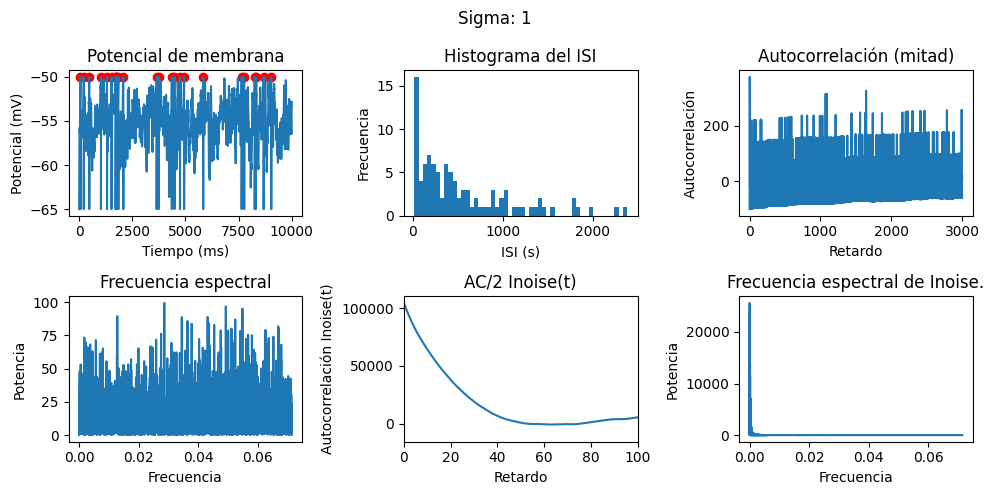

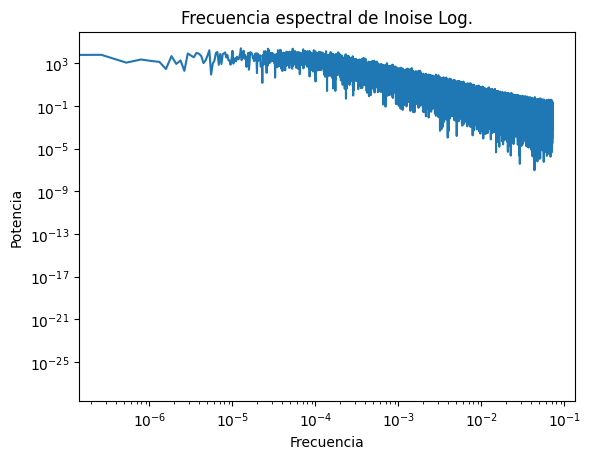

In [ ]:
simulacion_lif_noise(sigma1, Vth, Vrest, Vreset, Tm, R, Idet, dt, Ts)

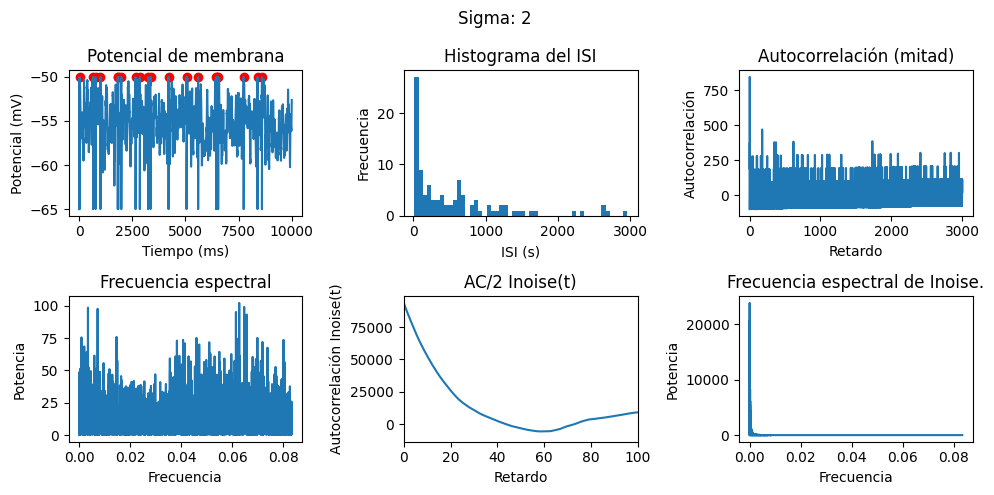

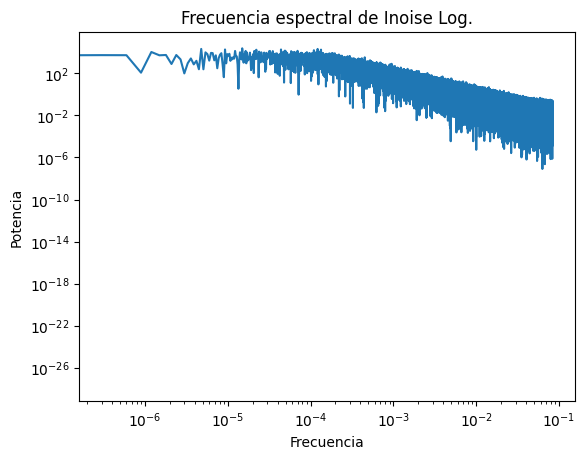

In [ ]:
simulacion_lif_noise(sigma2, Vth, Vrest, Vreset, Tm, R, Idet, dt, Ts)

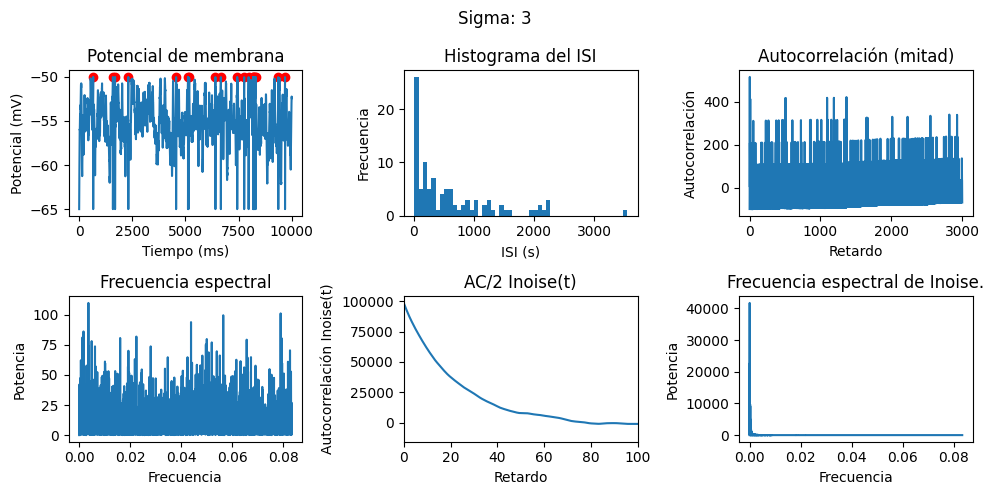

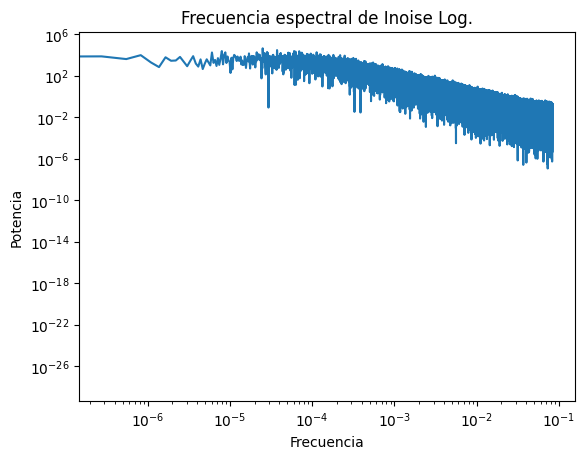

In [ ]:
simulacion_lif_noise(sigma3, Vth, Vrest, Vreset, Tm, R, Idet, dt, Ts)

La diferencia mas notable está en el histograma del ISI, en el ejercicio 1 se presenta un pico alto cerca de cero, lo que indica que hay muchos spikes en intervalos cortos. La distribución decrece progresivamente, con algunos valores extendiéndose a intervalos más largos, esto sugiere un patrón de disparo irregular, donde a veces la neurona dispara en ráfagas y otras veces tiene intervalos más largos entre spikes. En cambio para el segundo experimiento, al aplicarle una corriente externa (ruido de color) diferente, aunque también se ve un pico inicial alto, la cantidad de eventos en intervalos largos es menor en comparación con la primera imagen esto sugiere una mayor regularidad en los spikes, además hay menos dispersión en los valores del ISI, lo que podría indicar que los spikes ocurren con una frecuencia más constante.

En la imagen del potencial de membrana del segundo ejercicio, hay más spikes seguidos, lo que sugiere que la neurona está disparando con mayor frecuencia, muy similar al argumento dado en la parte anterior. Notamos también que la frecuencia espectral de la segunda imagen es un poco más suave pero con mayor oscilaciones.
